In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
# Instalação e download de modelos de NLP necessários para o processamento em português
!python -m spacy download pt_core_news_sm

import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textwrap import fill
from IPython.display import HTML, display

%matplotlib inline

# Download do dicionário de stopwords do NLTK
nltk.download('stopwords')

#
nltk.download('wordnet')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 34.4 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [39]:
# Configuração global de exibição textual
LARGURA_TEXTO_PADRAO = 110
MAX_COLWIDTH_DF = 140

pd.set_option('display.max_colwidth', MAX_COLWIDTH_DF)

def wrap_texto(texto, largura=LARGURA_TEXTO_PADRAO):
    if pd.isna(texto):
        return ''
    return fill(str(texto), width=largura)

# Aplica quebra de linha nas células de tabelas exibidas no notebook
display(HTML(f"""
<style>
table.dataframe td {{
  white-space: pre-wrap;
  word-break: break-word;
  max-width: {LARGURA_TEXTO_PADRAO}ch;
}}
</style>
"""))

In [40]:
basepath = '/content/drive/MyDrive/Fake.br-Corpus/full_texts/'

if not os.path.exists(basepath):
    print("Erro Crítico: A pasta 'full_texts' não foi encontrada no seu Drive. Verifique o caminho.")
    exit()

In [41]:
df = pd.read_csv('/content/drive/MyDrive/Fake.br-Corpus/fake.br-full_texts.csv')
print("Dimensões do DataFrame df:", df.shape)

Dimensões do DataFrame df: (7200, 28)


In [42]:
print("Nome das colunas do DataFrame df:", df.columns)
print("Tipos de dados das colunas do DataFrame df:\n", df.dtypes)

Nome das colunas do DataFrame df: Index(['id_original', 'texto_completo', 'label', 'autor', 'link_fonte',
       'categoria', 'data_publicacao', 'num_tokens',
       'num_palavras_sem_pontuacao', 'num_types', 'num_links_internos',
       'num_palavras_maiusculas', 'num_verbos', 'num_verbos_subj_imperativo',
       'num_substantivos', 'num_adjetivos', 'num_adverbios',
       'num_verbos_modais', 'num_pronomes_sing_1_2', 'num_pronomes_plu_1',
       'num_pronomes', 'pausabilidade', 'num_caracteres',
       'comprimento_medio_sentenca', 'comprimento_medio_palavra',
       'porcentagem_erros_ortograficos', 'emotividade', 'diversidade_lexical'],
      dtype='object')
Tipos de dados das colunas do DataFrame df:
 id_original                         int64
texto_completo                     object
label                               int64
autor                              object
link_fonte                         object
categoria                          object
data_publicacao                 

In [43]:
# 1. Corrige o problema da instalação interrompida (destrava o sistema)
!sudo dpkg --configure -a

# 2. Aceita a licença da Microsoft automaticamente
!echo ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true | sudo debconf-set-selections

# 3. Instala as fontes sem pedir confirmação interativa (-y)
!sudo apt-get install ttf-mscorefonts-installer -y

# 4. Limpa o cache de fontes do Matplotlib
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ttf-mscorefonts-installer is already the newest version (3.8ubuntu2).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [44]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 1. Baixa o arquivo original da fonte Arial diretamente para o Colab
!wget -q -O Arial.ttf https://github.com/matomo-org/travis-scripts/raw/master/fonts/Arial.ttf

# 2. Injeta o arquivo da fonte diretamente no cérebro do Matplotlib
fm.fontManager.addfont('Arial.ttf')

# 3. Define a Arial como a fonte padrão global
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

print("Fonte Arial forçada com sucesso! Pode rodar o código do gráfico agora.")

Fonte Arial forçada com sucesso! Pode rodar o código do gráfico agora.


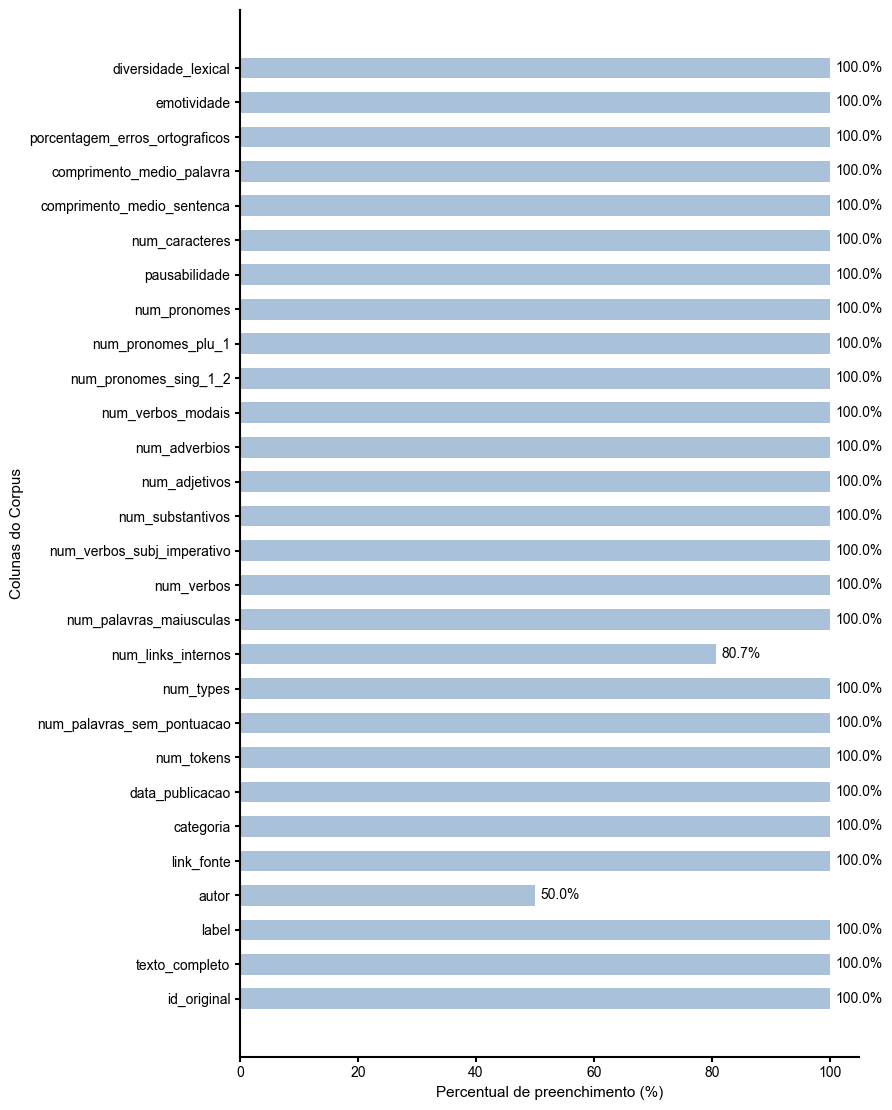

In [45]:
import matplotlib.pyplot as plt

# 1. Calcula o percentual de dados válidos (não-nulos) para cada coluna
preenchimento = (df.notnull().sum() / len(df)) * 100

# 2. Criação da figura com altura dinâmica
fig, ax = plt.subplots(figsize=(9, len(preenchimento) * 0.4)) 

# 3. Plota barras horizontais (cor neutra mantida, mas pode alterar se quiser)
barras = ax.barh(preenchimento.index, preenchimento.values, color='#A9C1D9', height=0.6)

# ==========================================
# 4. APLICAÇÃO DAS REGRAS DO TCC
# ==========================================

# Linhas de grade: Não deve conter
ax.grid(False)

# Preenchimento: Não deve conter (fundo transparente)
ax.set_facecolor('none')
fig.patch.set_facecolor('none')

# Borda: Não deve conter (removemos topo e direita, deixando os eixos na esquerda e base)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Eixos (principal horizontal e vertical): linha sólida, preta, 1,5 pt
for eixo in ['bottom', 'left']:
    ax.spines[eixo].set_color('black')
    ax.spines[eixo].set_linewidth(1.5)
    ax.spines[eixo].set_linestyle('-')

# Ajusta as marcações dos eixos (ticks) para 1.5pt
ax.tick_params(axis='both', colors='black', width=1.5)

# Títulos dos eixos: Arial, 11, preto
fonte_eixos = {'family': 'Arial', 'size': 11, 'color': 'black'}
ax.set_xlabel('Percentual de preenchimento (%)', fontdict=fonte_eixos)
ax.set_ylabel('Colunas do Corpus', fontdict=fonte_eixos)

# Título do gráfico: Removido (Não deve conter)

# Garante que as palavras nos eixos (os nomes das colunas e os números) também fiquem em Arial
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname('Arial')
    label.set_fontsize(10)
    label.set_color('black')

# 5. Opcional, mas útil: Insere os percentuais à direita de cada barra
for barra, percentual in zip(barras, preenchimento.values):
    ax.text(percentual + 1, # Um pouco à direita do fim da barra
            barra.get_y() + barra.get_height()/2, 
            f"{percentual:.1f}%", 
            va='center', 
            ha='left', 
            fontsize=10,
            fontname='Arial',
            color='black')

plt.tight_layout()
plt.show()

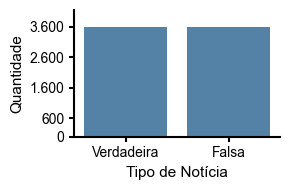

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker # <-- Importação necessária para o separador

# Criação da figura e do eixo
fig, ax = plt.subplots(figsize=(3, 2))

# Visualização gráfica da distribuição das classes
sns.countplot(x=df['label'], color='steelblue', ax=ax)

# ==========================================
# 1. DADOS, LIMITES E FORMATOS DO GRÁFICO
# ==========================================

# Define os rótulos do eixo X
ax.set_xticks([0, 1])
ax.set_xticklabels(['Verdadeira', 'Falsa'])

# Define os ticks do eixo Y para melhor visualização
ax.set_yticks([0, 600, 1600, 2600, 3600])

# Identifica o valor máximo exato e adiciona 15% de margem no limite Y
valor_maximo = df['label'].value_counts().max()
ax.set_ylim(0, valor_maximo * 1.15)

# --- NOVO: Formatador de Milhar com Ponto ---
def formatar_ponto_milhar(x, pos):
    # Formata com vírgula (padrão Python) e substitui por ponto
    return f"{int(x):,}".replace(',', '.')

# Aplica a formatação no eixo Y
ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatar_ponto_milhar))
# --------------------------------------------

# ==========================================
# 2. APLICAÇÃO DAS REGRAS DO TCC
# ==========================================

# Linhas de grade e preenchimento: Não deve conter
ax.grid(False)
ax.set_facecolor('none')
fig.patch.set_facecolor('none')

# Borda: Não deve conter (removendo topo e direita)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Eixos (principal horizontal e vertical): linha sólida, preta, 1,5 pt
for eixo in ['bottom', 'left']:
    ax.spines[eixo].set_color('black')
    ax.spines[eixo].set_linewidth(1.5)
    ax.spines[eixo].set_linestyle('-')

# Ajuste das marcações (tracinhos dos ticks) para acompanhar os eixos
ax.tick_params(axis='both', colors='black', width=1.5)

# Títulos dos eixos: Arial, 11, preto
fonte_eixos = {'family': 'Arial', 'size': 11, 'color': 'black'}
ax.set_xlabel('Tipo de Notícia', fontdict=fonte_eixos)
ax.set_ylabel('Quantidade', fontdict=fonte_eixos)
ax.set_title('') 

# Garante que os textos dos ticks fiquem em Arial
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname('Arial')
    label.set_fontsize(10)
    label.set_color('black')

plt.tight_layout()
plt.show()

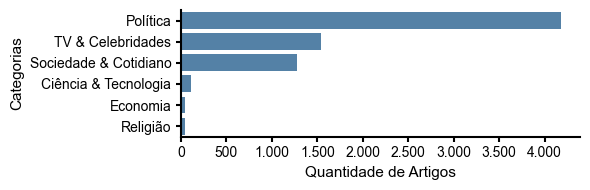

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Criação da figura e do eixo (largura ajustada para caber os nomes das categorias)
fig, ax = plt.subplots(figsize=(6, 2))

# 2. Plota o gráfico com uma cor uniforme
sns.countplot(y=df['categoria'], color='steelblue', ax=ax)

# ==========================================
# 3. DADOS, LIMITES E FORMATOS DO GRÁFICO
# ==========================================

# Define os rótulos do eixo Y com as categorias
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.set_yticklabels(['Política', 'TV & Celebridades', 'Sociedade & Cotidiano', 
                    'Ciência & Tecnologia', 'Economia', 'Religião'])

# Formatador de milhar com ponto (aplicado no eixo X)
def formatar_ponto_milhar(x, pos):
    return f"{int(x):,}".replace(',', '.')

ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatar_ponto_milhar))

# ==========================================
# 4. APLICAÇÃO DAS REGRAS DO TCC
# ==========================================

# Linhas de grade e preenchimento: Não deve conter
ax.grid(False)
ax.set_facecolor('none')
fig.patch.set_facecolor('none')

# Borda: Não deve conter (removendo topo e direita)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Eixos (principal horizontal e vertical): linha sólida, preta, 1,5 pt
for eixo in ['bottom', 'left']:
    ax.spines[eixo].set_color('black')
    ax.spines[eixo].set_linewidth(1.5)
    ax.spines[eixo].set_linestyle('-')

# Ajuste das marcações (tracinhos dos ticks) para acompanhar os eixos
ax.tick_params(axis='both', colors='black', width=1.5)

# Títulos dos eixos: Arial, 11, preto
fonte_eixos = {'family': 'Arial', 'size': 11, 'color': 'black'}
ax.set_xlabel('Quantidade de Artigos', fontdict=fonte_eixos)
ax.set_ylabel('Categorias', fontdict=fonte_eixos)

# Título do gráfico: Removido (Não deve conter)
ax.set_title('')

# Garante que os textos dos ticks fiquem em Arial
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname('Arial')
    label.set_fontsize(10)
    label.set_color('black')

plt.tight_layout()
plt.show()

In [48]:
# df = df[['label', 'texto_completo', 'categoria']]
# print(df['label'].value_counts())
# print("Dimensões do Dataset:", df.shape)

In [49]:
# All Stopwords
nlp = spacy.load('pt_core_news_sm')
stopwords_spacy = nlp.Defaults.stop_words
stopwords_nltk = stopwords.words('portuguese')
all_stopwords = list(stopwords_spacy.union(set(stopwords_nltk)))

In [50]:
lemma=WordNetLemmatizer()
lemma

<WordNetLemmatizer>

In [51]:
STOPWORDS_SET = set(all_stopwords)

def ensure_text(text):
  return '' if pd.isna(text) else str(text)

def lowercase_text(text):
  return text.lower()

def remove_special_chars(text):
  # Preserva letras acentuadas e dígitos
  return re.sub(r'[-()"#/@;:<>{}`+=~|.!?,]', ' ', text)

def normalize_whitespace(text):
  return re.sub(r'\s+', ' ', text).strip()

def remove_stopwords_and_lemmatize(text):
  tokens_limpos = []
  for word in text.split():
    if word not in STOPWORDS_SET:
      tokens_limpos.append(lemma.lemmatize(word))
  return ' '.join(tokens_limpos)

TEXT_CLEANING_PIPELINE = (
  ensure_text,
  lowercase_text,
  remove_special_chars,
  normalize_whitespace,
  remove_stopwords_and_lemmatize,
)

def text_cleaning(text):
  for step in TEXT_CLEANING_PIPELINE:
    text = step(text)
  return text

In [ ]:
# Execução da limpeza de texto criando a feature limpa
df['texto_limpo'] = df['texto_completo'].apply(text_cleaning)


In [53]:
# Seleciona um texto real do corpus para demonstração
texto_exemplo = df['texto_completo'].dropna().astype(str).iloc[0]
num_palavras_original = len(texto_exemplo.split())

print(f"Texto Original (palavras: {num_palavras_original}):\n")
print(wrap_texto(texto_exemplo))


Texto Original (palavras: 182):

Kátia Abreu diz que vai colocar sua expulsão em uma moldura, mas não para de reclamar.    A senadora Kátia
Abreu (sem partido-TO) disse que sua expulsão do PMDB foi resultado de uma ação da cúpula atual da legenda
que, segundo ela, é oportunista.  “Amanhã eu vou botar numa moldura dourada a minha expulsão, porque das mãos
de onde veio, é um atestado de boa conduta para o meu currículo. Essas pessoas que me expulsaram não servem ao
país. Eles se servem do país em seus benefícios próprios”, disse Kátia Abreu.  Ué, mas se a expulsão é algo
tão bom para seu currículo, por que tanta choradeira, Kátia?  Sabemos o motivo. Provavelmente Kátia não tem
valor para o PT, partido que já deveria tê-la absorvido. Ao que parece o PT gostava de Kátia somente se ela
ficasse entrincheirada dentro do PMDB.  Ou seja, isso é se rebaixar demais. Resta a Kátia ficar chorando as
pitangas por todos os cantos.  Em tempo: até o momento o PT não cadastrou Kátia Abreu em suas fileir

In [54]:
# Aplica a função de limpeza ao texto de exemplo
texto_limpo_exemplo = text_cleaning(texto_exemplo).strip()
num_palavras_limpo = len(texto_limpo_exemplo.split())
compactacao_pct = 0 if num_palavras_original == 0 else ((num_palavras_original - num_palavras_limpo) / num_palavras_original) * 100

print(f"\nTexto Limpo (palavras: {num_palavras_limpo} | compactação: {compactacao_pct:.1f}%):\n")
print(wrap_texto(texto_limpo_exemplo))


Texto Limpo (palavras: 81 | compactação: 55.5%):

kátia abreu colocar expulsão moldura reclamar senadora kátia abreu partido to disse expulsão pmdb resultado
ação cúpula atual legenda oportunista “amanhã vou botar moldura dourada expulsão mãos veio atestado conduta
currículo pessoas expulsaram servem país servem país benefícios próprios” disse kátia abreu ué expulsão
currículo choradeira kátia sabemos motivo provavelmente kátia pt partido deveria tê la absorvido pt gostava
kátia ficasse entrincheirada pmdb rebaixar resta kátia ficar chorando pitanga canto pt cadastrou kátia abreu
fileiras situação patética ex ministra agricultura dilma


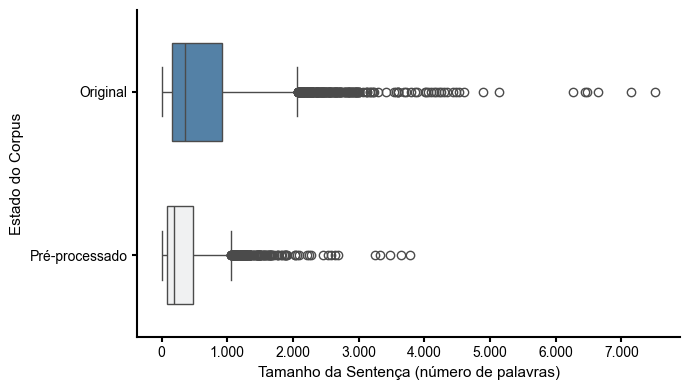

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Criação das colunas
if 'num_palavras_texto' not in df.columns:
    df['num_palavras_texto'] = df['texto_completo'].fillna('').astype(str).str.split().str.len()

if 'clean_text' not in df.columns:
    df['clean_text'] = df['texto_completo'].apply(text_cleaning)

df['num_palavras_limpo'] = df['clean_text'].fillna('').astype(str).str.split().str.len()

# 2. Calcula a redução antes de plotar
reducao_media_pct = ((df['num_palavras_texto'] - df['num_palavras_limpo']) / df['num_palavras_texto'].replace(0, pd.NA)).mean() * 100

# 3. Preparação dos dados para o Boxplot
dados = pd.DataFrame({
    'Tamanho': df['num_palavras_texto'].tolist() + df['num_palavras_limpo'].tolist(),
    'Corpus': ['Original'] * len(df) + ['Pré-processado'] * len(df)
})

# 4. Criação da figura e do eixo
fig, ax = plt.subplots(figsize=(7, 4)) # Altura levemente reduzida para o formato horizontal

# ==========================================
# 5. GERAÇÃO DO GRÁFICO (Horizontal)
# ==========================================

# Cria dois tons a partir do steelblue
tons_steelblue = sns.light_palette("steelblue", n_colors=2, reverse=True)

# INVERSÃO AQUI: x recebe os números (Tamanho) e y recebe as categorias (Corpus)
sns.boxplot(x='Tamanho', y='Corpus', data=dados, hue='Corpus', palette=tons_steelblue, legend=False, ax=ax)

# ==========================================
# 6. DADOS, LIMITES E FORMATOS DO GRÁFICO
# ==========================================

# Formatador de milhar com ponto (AGORA NO EIXO X)
def formatar_ponto_milhar(x, pos):
    return f"{int(x):,}".replace(',', '.')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatar_ponto_milhar))

# ==========================================
# 7. APLICAÇÃO DAS REGRAS DO TCC
# ==========================================

# Linhas de grade e preenchimento: Não deve conter
ax.grid(False)
ax.set_facecolor('none')
fig.patch.set_facecolor('none')

# Borda: Não deve conter (removendo topo e direita)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Eixos (principal horizontal e vertical): linha sólida, preta, 1,5 pt
for eixo in ['bottom', 'left']:
    ax.spines[eixo].set_color('black')
    ax.spines[eixo].set_linewidth(1.5)
    ax.spines[eixo].set_linestyle('-')

# Ajuste das marcações (tracinhos dos ticks)
ax.tick_params(axis='both', colors='black', width=1.5)

# Títulos dos eixos: Arial, 11, preto (INVERTIDOS AQUI TAMBÉM)
fonte_eixos = {'family': 'Arial', 'size': 11, 'color': 'black'}
ax.set_xlabel('Tamanho da Sentença (número de palavras)', fontdict=fonte_eixos)
ax.set_ylabel('Estado do Corpus', fontdict=fonte_eixos)

# Remoção do título do gráfico
ax.set_title('')

# Garante que os textos dos ticks fiquem em Arial
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname('Arial')
    label.set_fontsize(10)
    label.set_color('black')


plt.tight_layout()
plt.show()

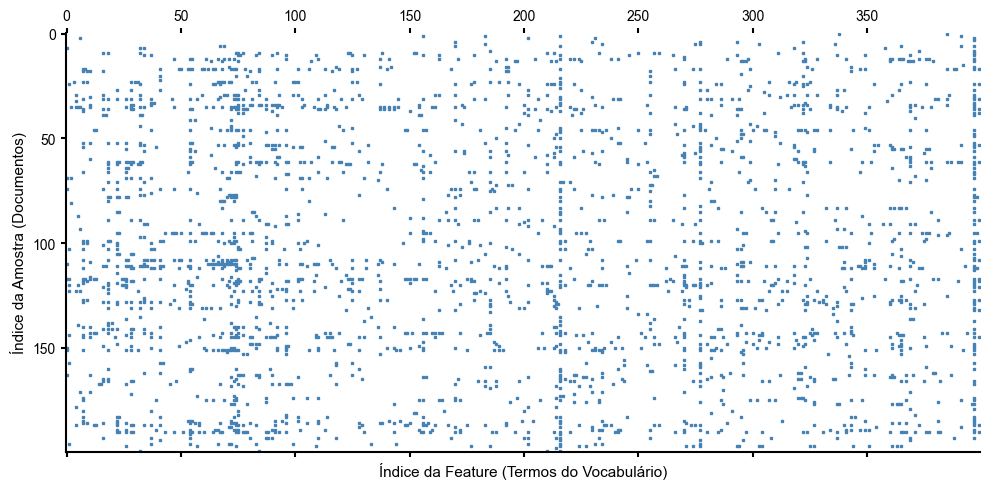

In [68]:
import matplotlib.pyplot as plt

# 1. Amostra da matriz
amostra_matriz = X_train_tfidf[:200, :400].toarray()

# 2. Configura a área do gráfico
fig, ax = plt.subplots(figsize=(10, 5))

# 3. Plota os pontos não nulos
# Mantemos o steelblue conforme solicitado
ax.spy(amostra_matriz, markersize=2, color='steelblue', aspect='auto')

# ==========================================
# 4. APLICAÇÃO DAS REGRAS DO TCC
# ==========================================

# Linhas de grade: Não deve conter
ax.grid(False)

# Eixos (principal horizontal e vertical): linha sólida, preta, 1,5 pt
for eixo in ['bottom', 'left']:
    ax.spines[eixo].set_color('black')
    ax.spines[eixo].set_linewidth(1.5)
    ax.spines[eixo].set_linestyle('-')

# Borda (topo e direita): Não deve conter
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Títulos dos eixos: Arial, 11, preto
fonte_eixos = {'family': 'Arial', 'size': 11, 'color': 'black'}
ax.set_xlabel('Índice da Feature (Termos do Vocabulário)', fontdict=fonte_eixos)
ax.set_ylabel('Índice da Amostra (Documentos)', fontdict=fonte_eixos)

# Título do gráfico: Removido
ax.set_title('')

# Ajuste das marcações (tracinhos dos ticks)
ax.tick_params(axis='both', colors='black', width=1.5)

# Garante que os textos dos ticks fiquem em Arial
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname('Arial')
    label.set_fontsize(10)
    label.set_color('black')

# 5. CÁLCULOS E CAIXA EXPLICATIVA
densidade_global = (X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100
esparsidade_global = 100 - densidade_global

texto_explicativo = (
    f"Densidade Global: {densidade_global:.2f}%\n"
    f"Esparsidade: {esparsidade_global:.1f}%"
)


fig.tight_layout()
plt.show()

In [56]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
print(y_test)

3098    1
2531    1
4071    0
1287    1
2540    1
       ..
3790    0
911     1
6520    0
2995    1
3341    1
Name: label, Length: 1440, dtype: int64


In [58]:
# TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Configuração do TfidfVectorizer para texto em português, considerando unigrams e bigrams, e limitando o número de features
vectorizer = TfidfVectorizer(
    lowercase=True,
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [59]:
print(vectorizer)

TfidfVectorizer(max_df=0.95, max_features=5000, min_df=2, ngram_range=(1, 2),
                sublinear_tf=True)


In [60]:
# Aplicação do TF-IDF ao conjunto de treinamento


# Fit only on training data to avoid data leakage
X_train_tfidf = vectorizer.fit_transform(X_train)
tfidf_terms = vectorizer.get_feature_names_out()
tfidf_idf = pd.Series(vectorizer.idf_, index=tfidf_terms).sort_values(ascending=False)

print(f"Matriz TF-IDF de treino: {X_train_tfidf.shape[0]} documentos x {X_train_tfidf.shape[1]} termos")
print(f"Não zeros na matriz: {X_train_tfidf.nnz}")
print(f"Densidade da matriz: {X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.6f}")

Matriz TF-IDF de treino: 5760 documentos x 5000 termos
Não zeros na matriz: 923651
Densidade da matriz: 0.032071


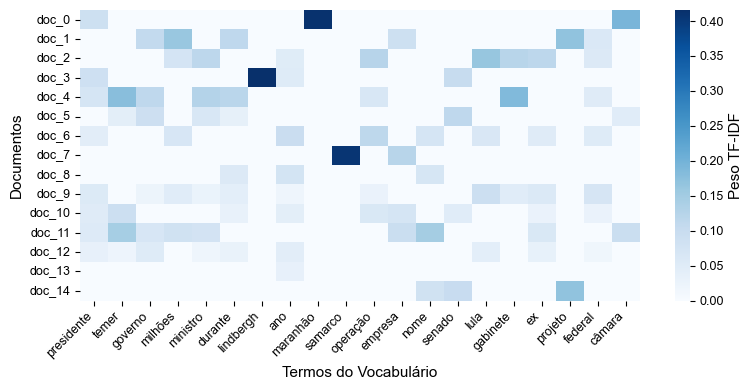

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparação dos dados
n_docs = min(15, X_train_tfidf.shape[0])
sample_matrix = X_train_tfidf[:n_docs]
term_strength = np.asarray(sample_matrix.sum(axis=0)).ravel()
top_idx = np.argsort(term_strength)[::-1][:20] # Reduzi para 20 termos para a legibilidade

heat_data = sample_matrix[:, top_idx].toarray()
heat_terms = [tfidf_terms[i] for i in top_idx]

# 2. Criação da figura e eixo
fig, ax = plt.subplots(figsize=(8, 4))

# 3. Plotagem do Heatmap
# Usamos 'Blues' que escala harmoniosamente com o steelblue
sns.heatmap(
    heat_data,
    cmap='Blues', 
    cbar_kws={'label': 'Peso TF-IDF'},
    xticklabels=heat_terms,
    yticklabels=[f'doc_{i}' for i in range(n_docs)],
    ax=ax
)

# ==========================================
# 4. APLICAÇÃO DAS REGRAS DO TCC
# ==========================================

# Título do gráfico: Removido
ax.set_title('')

# Títulos dos eixos: Arial, 11, preto
fonte_eixos = {'family': 'Arial', 'size': 11, 'color': 'black'}
ax.set_xlabel('Termos do Vocabulário', fontdict=fonte_eixos)
ax.set_ylabel('Documentos', fontdict=fonte_eixos)

# Garante que os textos dos ticks fiquem em Arial
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname('Arial')
    label.set_fontsize(9)
    label.set_color('black')

# Formatação específica da legenda de cores (Colorbar)
cbar = ax.collections[0].colorbar
cbar.set_label('Peso TF-IDF', fontname='Arial', fontsize=11, color='black')
for label in cbar.ax.get_yticklabels():
    label.set_fontname('Arial')
    label.set_fontsize(9)
    label.set_color('black')

# Rotação dos termos no eixo X para melhor legibilidade
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [62]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression

print("## Classificação Binária (Real vs Fake) com TF-IDF")

# Garante transformação do conjunto de teste com o mesmo vetorizador treinado
X_test_tfidf = vectorizer.transform(X_test)


# 1) Linear SVC
modelo_svc = LinearSVC()
modelo_svc.fit(X_train_tfidf, y_train)
pred_svc = modelo_svc.predict(X_test_tfidf)

print("\n### Linear SVC")
print(classification_report(y_test, pred_svc, target_names=["Real", "Fake"]))
print(f"Acurácia (Linear SVC): {accuracy_score(y_test, pred_svc):.4f}")

# 2) Logistic Regression

modelo_lr = LogisticRegression(max_iter=1000, solver="liblinear")
modelo_lr.fit(X_train_tfidf, y_train)
pred_lr = modelo_lr.predict(X_test_tfidf)

print("\n### Logistic Regression")
print(classification_report(y_test, pred_lr, target_names=["Real", "Fake"]))
print(f"Acurácia (Logistic Regression): {accuracy_score(y_test, pred_lr):.4f}")

## Classificação Binária (Real vs Fake) com TF-IDF

### Linear SVC
              precision    recall  f1-score   support

        Real       0.97      0.97      0.97       722
        Fake       0.97      0.97      0.97       718

    accuracy                           0.97      1440
   macro avg       0.97      0.97      0.97      1440
weighted avg       0.97      0.97      0.97      1440

Acurácia (Linear SVC): 0.9667

### Logistic Regression
              precision    recall  f1-score   support

        Real       0.97      0.95      0.96       722
        Fake       0.95      0.97      0.96       718

    accuracy                           0.96      1440
   macro avg       0.96      0.96      0.96      1440
weighted avg       0.96      0.96      0.96      1440

Acurácia (Logistic Regression): 0.9597


In [72]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

def extrair_metricas(y_true, y_pred, nome_modelo, acuracia):
    # Calcula as métricas
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    return {
        "Modelo": nome_modelo,
        "Precisão": p,
        "Recall": r,
        "F1-Score": f,
        "Acurácia": acuracia
    }

# Coleta os dados
resultados = [
    extrair_metricas(y_test, pred_svc, "Linear SVC", accuracy_score(y_test, pred_svc)),
    extrair_metricas(y_test, pred_lr, "Logistic Regression", accuracy_score(y_test, pred_lr))
]

# Cria o DataFrame
df_resultados = pd.DataFrame(resultados)

# Formata os números para 4 casas decimais (essencial para o alinhamento à direita)
df_formatado = df_resultados.copy()
colunas_numericas = ["Precisão", "Recall", "F1-Score", "Acurácia"]
for col in colunas_numericas:
    df_formatado[col] = df_formatado[col].map('{:.4f}'.format)

print(df_formatado.to_string(index=False))

             Modelo Precisão Recall F1-Score Acurácia
         Linear SVC   0.9667 0.9667   0.9667   0.9667
Logistic Regression   0.9598 0.9597   0.9597   0.9597


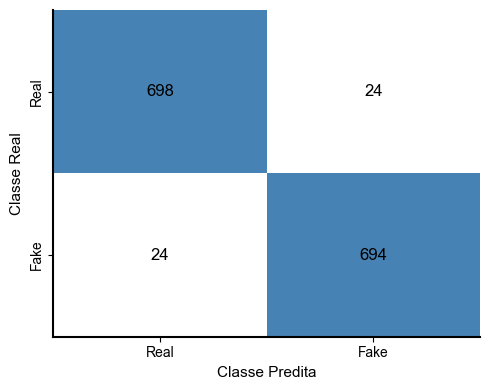

In [82]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# 1. Calcula a matriz
cm = confusion_matrix(y_test, pred_svc)

# 2. Criação da figura
fig, ax = plt.subplots(figsize=(5, 4))

# 3. Criação de um gradiente personalizado baseado EXATAMENTE em 'steelblue'
# Isso garante que ele não pule para outros tons de azul
cmap = mcolors.LinearSegmentedColormap.from_list("", ["#ffffff", "steelblue"])

# 4. Plota o Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, 
            xticklabels=['Real', 'Fake'], 
            yticklabels=['Real', 'Fake'], 
            cbar=False, ax=ax, 
            annot_kws={"fontname": "Arial", "fontsize": 12, "color": "black"})

# ==========================================
# 5. APLICAÇÃO DAS REGRAS DO TCC
# ==========================================

ax.set_title('')
fonte_eixos = {'family': 'Arial', 'size': 11, 'color': 'black'}
ax.set_xlabel('Classe Predita', fontdict=fonte_eixos)
ax.set_ylabel('Classe Real', fontdict=fonte_eixos)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname('Arial')
    label.set_fontsize(10)
    label.set_color('black')

# Remove as bordas do seaborn (grid do heatmap)
for spine in ax.spines.values():
    spine.set_visible(False)

# Adiciona as linhas externas obrigatórias (base e esquerda)
for eixo in ['bottom', 'left']:
    ax.spines[eixo].set_visible(True)
    ax.spines[eixo].set_color('black')
    ax.spines[eixo].set_linewidth(1.5)

plt.tight_layout()
plt.show()